In [1]:
# Import the required libraries.

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Load the cleaned dataset with datetime parsing.

shipments = pd.read_csv(
    "../Dataset/cleaned_shipments.csv",
    parse_dates=[
        "departure_timestamp",
        "expected_arrival_timestamp",
        "actual_arrival_timestamp"
    ]
)

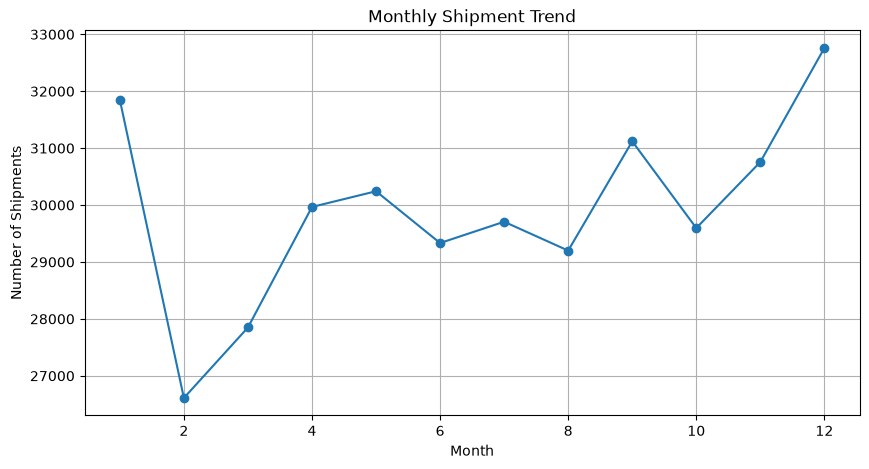

In [5]:
# Q1. Visualize the monthly shipment trend.

monthly_shipments = shipments.groupby(
    shipments["departure_timestamp"].dt.month
).size()

monthly_shipments.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Shipment Trend")
plt.xlabel("Month")
plt.ylabel("Number of Shipments")
plt.grid(True)

plt.show()

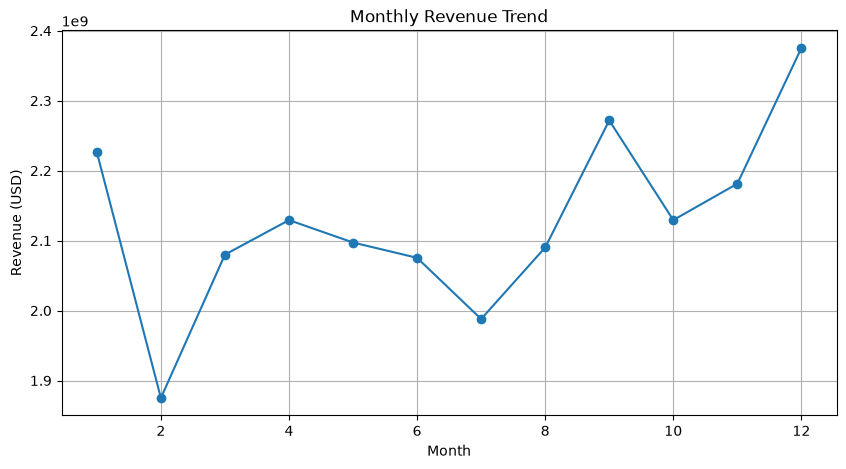

In [6]:
# Q2. Visualize the monthly shipment revenue.

monthly_revenue = shipments.groupby(
    shipments["departure_timestamp"].dt.month
)["shipment_value_usd"].sum()

monthly_revenue.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.grid(True)

plt.show()

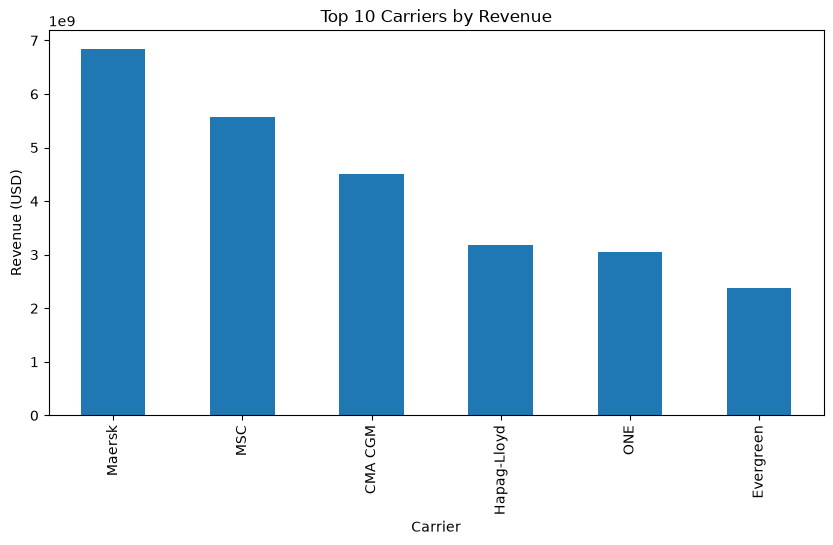

In [7]:
# Q3. Visualize the top 10 carriers by shipment revenue.

carrier_revenue = shipments.groupby("carrier_name")[
    "shipment_value_usd"
].sum().sort_values(ascending=False).head(10)

carrier_revenue.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Carriers by Revenue")
plt.xlabel("Carrier")
plt.ylabel("Revenue (USD)")

plt.show()

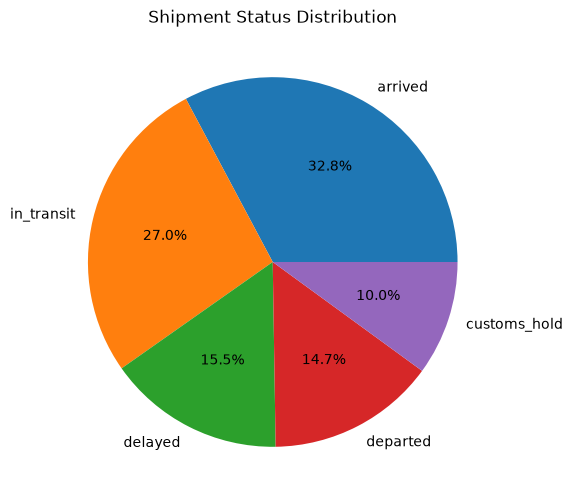

In [8]:
# Q4. Visualize shipment status distribution.

shipment_status = shipments["status"].value_counts()

shipment_status.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Shipment Status Distribution")
plt.ylabel("")

plt.show()

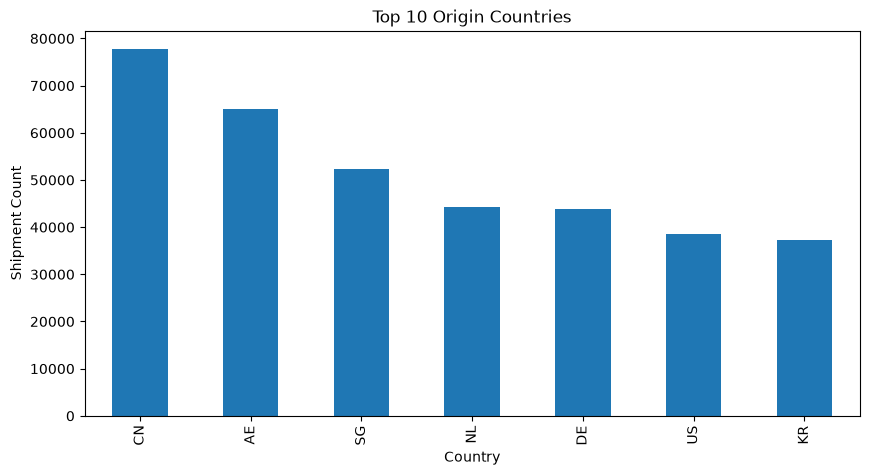

In [9]:
# Q5. Visualize the top 10 origin countries by shipment count.

origin_country = shipments["origin_country"].value_counts().head(10)

origin_country.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Origin Countries")
plt.xlabel("Country")
plt.ylabel("Shipment Count")

plt.show()